In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pyprojroot import here
import os
import importlib

In [2]:
colors=["#0091ff",'#f2d138', '#7fc960', "#a589ee"] #majority/minority
maj_color = colors[0]
min_color = colors[1]
min_maj_color = colors[2]
maj_min_color = colors[3]
greycolor='#626262'
lightgreycolor='#c4c4c4'
myblack='#222222'


SMALL_SIZE = 8
MEDIUM_SIZE = 9
BIGGER_SIZE = 12

# --- FONT SIZES ----------------------------------------------------------
TITLE_SIZE = 9
LABEL_SIZE = 8
TICK_SIZE = 8
ANNOT_SIZE = 7
LEGEND_SIZE = 7

linewidth=0.5
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

def customize_axes(ax,myblack):
    ax.spines['top'].set_color(myblack)
    ax.spines['bottom'].set_color(myblack)
    ax.spines['left'].set_color(myblack)
    ax.spines['right'].set_color(myblack)
    ax.xaxis.label.set_color(myblack)
    ax.yaxis.label.set_color(myblack)
    ax.title.set_color(myblack)
    ax.tick_params(axis='x', colors=myblack)
    ax.tick_params(axis='y', colors=myblack)

In [3]:

src_path = os.path.join(here(), "03_analytical", "src", "functions.py")

spec = importlib.util.spec_from_file_location("fun", src_path)
fun = importlib.util.module_from_spec(spec)
spec.loader.exec_module(fun)


In [4]:
## define model parameters

No = 333 # number of opponents
Ns = 1000-No  # number of supporters
N = No + Ns # total number of agents
fs = Ns / N # fraction of supporters
fo = No / N # fraction of opponents


hss = 0.5 # homophily supporter-supporter
hso = 1 - hss # homophily supporter-opponent, following Karimi et al. (2018)
hoo = 0.5 # homophily opponent-opponent
hos = 1 - hoo # homophily opponent-supporter

In [5]:
def G1_orig(H_in, H_out, min_fraction, eps=1e-10):
    maj_fraction = 1 - min_fraction
    den = np.maximum(maj_fraction * H_in + min_fraction * H_out, eps)
    return maj_fraction - (maj_fraction * H_in) / den

def G2_orig(H_in, H_out, min_fraction, eps=1e-10):
    maj_fraction = 1 - min_fraction
    den = np.maximum(maj_fraction * H_out + min_fraction * H_in, eps)
    return maj_fraction - (maj_fraction * H_out) / den

In [6]:
# --- 3-panel heatmaps for beta_o, beta_s, beta_overall with contours ---
n_points = 101
h_in_supp_vals = np.linspace(0, 1, n_points)
h_in_opp_vals = np.linspace(0, 1, n_points)
h_out = 0.3
# Containers
mis_o_SBM = np.zeros((n_points, n_points))
mis_s_SBM = np.zeros((n_points, n_points))
mis_overall_SBM = np.zeros((n_points, n_points))

for i, h_in_opp in enumerate(h_in_opp_vals):
    for j, h_in_supp in enumerate(h_in_supp_vals):
        # Misperceptions
        beta_s = G1_orig(h_in_supp, h_out, fo, eps=1e-10)
        beta_o = G2_orig(h_in_opp, h_out, fo, eps=1e-10)
        beta_overall = fun.compute_overall_misperception(fs, beta_o, beta_s)

        mis_o_SBM[i, j] = beta_o
        mis_s_SBM[i, j] = beta_s
        mis_overall_SBM[i, j] = beta_overall

print(np.max(mis_o_SBM))
print(np.max(mis_s_SBM))
print(np.max(mis_overall_SBM))
print(np.argmax(mis_overall_SBM))

0.29164828362408557
0.667
0.5420078784468205
10100


In [7]:
# --- 3-panel heatmaps for beta_o, beta_s, beta_overall with contours ---
n_points = 101
hss_vals = np.linspace(0, 1, n_points)
hoo_vals = np.linspace(0, 1, n_points)

# Containers
mis_o = np.zeros((n_points, n_points))
mis_s = np.zeros((n_points, n_points))
mis_overall = np.zeros((n_points, n_points))

for i, hoo in enumerate(hoo_vals):
    for j, hss in enumerate(hss_vals):
        hso = 1 - hss
        hos = 1 - hoo

        # Solve for C
        C = fun.compute_C(fo, fs, hoo, hos, hso, hss)

        # Probabilities
        p_oo = fun.compute_p_oo(hoo, hos, C)
        p_ss = fun.compute_p_ss(hss, hso, C)
        p_os = fun.compute_p_os(hos, hoo, C)
        p_so = fun.compute_p_so(hso, hss, C)

        # Misperceptions
        beta_o = fun.compute_misperception(fs, fun.compute_opponent_perception(No, Ns, p_os, p_so, p_oo))
        beta_s = fun.compute_misperception(fs, fun.compute_supporter_perception(No, Ns, p_os, p_so, p_ss))
        beta_overall = fun.compute_overall_misperception(fs, beta_o, beta_s)

        mis_o[i, j] = beta_o
        mis_s[i, j] = beta_s
        mis_overall[i, j] = beta_overall

# Shared color scale across panels
vmax = max(abs(mis_o).max(), abs(mis_s).max(), abs(mis_overall).max())
vmin = -vmax

# Shared color scale across all panels
vmax = max(
    abs(mis_o).max(), abs(mis_s).max(), abs(mis_overall).max(),
    abs(mis_o_SBM).max(), abs(mis_s_SBM).max(), abs(mis_overall_SBM).max()
)
vmin = -vmax

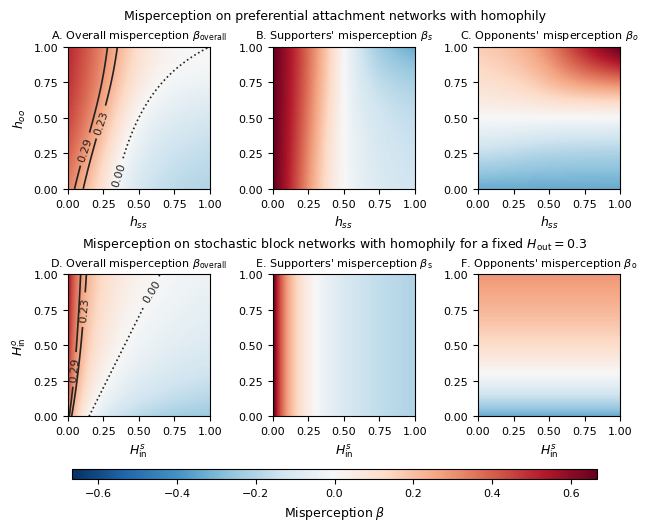

In [8]:
# --- Shared color scale (placeholder: symmetric around 0) ---
vmax = max(
    abs(mis_o).max(), abs(mis_s).max(), abs(mis_overall).max(),
    abs(mis_o_SBM).max(), abs(mis_s_SBM).max(), abs(mis_overall_SBM).max()
)
vmin = -vmax

# --- Figure and axes: 2 rows x 3 columns ---
fig, axes = plt.subplots(2, 3, figsize=(7.5, 4.8), constrained_layout=False)
plt.subplots_adjust(hspace=0.6)     # <-- increase this number for more separation

# Flatten axes for easy iteration
axes_flat = axes.ravel()

# --- Datasets & titles for 6 panels ---
datasets = [
    (mis_overall,     r"A. Overall misperception $\beta_{\mathrm{overall}}$"),
    (mis_s,           r"B. Supporters' misperception $\beta_{s}$"),
    (mis_o,           r"C. Opponents' misperception $\beta_{o}$"),
    (mis_overall_SBM, r"D. Overall misperception $\beta_{\mathrm{overall}}$"),
    (mis_s_SBM,       r"E. Supporters' misperception $\beta_{\text{s}}$"),
    (mis_o_SBM,       r"F. Opponents' misperception $\beta_{\text{o}}$"),
]

tick_vals = np.linspace(0, 1, 5)

ims = []
for idx, (ax, (data, title)) in enumerate(zip(axes_flat, datasets)):

    # --- Render heatmap ---
    im = ax.imshow(
        data,
        extent=[0, 1, 0, 1],
        origin="lower",
        cmap="RdBu_r",
        vmin=vmin, vmax=vmax,
        aspect="equal",  # make panels square
    )
    ims.append(im)

    ax.set_xticks(tick_vals)
    ax.set_yticks(tick_vals)

    # --- Axis labels ---
    row = idx // 3  # 0 for analytic row, 1 for SBM row
    col = idx % 3

    if row == 0:
        # Analytic model labels
        if col == 0:
            ax.set_ylabel(r"$h_{oo}$")
        else:
            ax.set_ylabel("")
        ax.set_xlabel(r"$h_{ss}$")

    else:
        # SBM labels
        if col == 0:
            ax.set_ylabel(r"$H_{\text{in}}^o$")
        else:
            ax.set_ylabel("")
        ax.set_xlabel(r"$H_{\text{in}}^s$")

    ax.set_title(title)


# --- Contours on first panel (BA overall) ---
X, Y = np.meshgrid(hss_vals, hoo_vals)
contours = axes[0,0].contour(
    X, Y, mis_overall,
    levels=[0.66 - 0.43, 0.66 - 0.37],
    colors=[myblack],
    linewidths=1.2
)
axes[0,0].clabel(contours, inline=True, fmt="%.2f", fontsize=8, colors=[myblack])

# Zero contour on BA overall (dotted, labeled)
zero_ctr = axes[0,0].contour(
    X, Y, mis_overall,
    levels=[0],
    colors=[myblack],
    linewidths=1.2,
    linestyles='dotted'
)
axes[0,0].clabel(zero_ctr, inline=True, fmt="%.2f", fontsize=8, colors=[myblack])

# --- Contours on bottom left panel (SBM overall) ---
X2, Y2 = np.meshgrid(h_in_supp_vals, h_in_opp_vals)
contours2 = axes[1,0].contour(
    X2, Y2, mis_overall_SBM,
    levels=[0.66 - 0.43, 0.66 - 0.37],
    colors=[myblack],
    linewidths=1.2
)
axes[1,0].clabel(contours2, inline=True, fmt="%.2f", fontsize=8, colors=[myblack])

# Zero contour on SBM overall (dotted, labeled)
zero_ctr2 = axes[1,0].contour(
    X2, Y2, mis_overall_SBM,
    levels=[0],
    colors=[myblack],
    linewidths=1.2,
    linestyles='dotted'
)
axes[1,0].clabel(zero_ctr2, inline=True, fmt="%.2f", fontsize=8, colors=[myblack])


# --- Shared colorbar underneath ---
cbar_ax = fig.add_axes([0.15, -0.02, 0.70, 0.02])

cbar = fig.colorbar(
    ims[-1],
    cax=cbar_ax,
    orientation="horizontal"
)

cbar.set_label(r"Misperception $\beta$")

# --- Row labels ---
fig.text(0.5, 0.945, "Misperception on preferential attachment networks with homophily", ha="center", va="center", fontsize=TITLE_SIZE)
fig.text(0.5, 0.47, rf"Misperception on stochastic block networks with homophily for a fixed $H_{{\text{{out}}}} = {h_out}$", ha="center", va="center", fontsize=TITLE_SIZE)

plt.savefig(here("figures/figure_2.pdf"), dpi=300, bbox_inches='tight')

plt.show()
